# 🌱 PlantWhisper - Full Integration Demo

**"Listen to what your plants are trying to tell you"**

Complete pipeline:
- Photo → SAM Segmentation → Classification → Stress Estimation → Audio + Voice

---

## Features
1. **Vision Pipeline**: SAM segmentation + MobileNetV2 classifier + Grad-CAM explainability
2. **Stress Estimation**: Science-based stress level from visual analysis
3. **Acoustic Synthesis**: Real Tel Aviv ultrasonic pops, pitch-shifted to audible range
4. **Plant Persona**: LLM-generated speech (Groq) + Text-to-Speech (Edge-TTS)
5. **Combined Output**: Visualization + layered audio experience

In [1]:
# ============================================
# 1. Install All Dependencies
# ============================================
!pip install -q transformers torch torchvision torchaudio
!pip install -q segment-anything
!pip install -q opencv-python matplotlib
!pip install -q groq edge-tts nest_asyncio
!pip install -q scipy librosa soundfile pydub
!pip install -q grad-cam

# Download SAM checkpoint
!wget -q https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth -O /content/sam_vit_b.pth

print("✓ All dependencies installed")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.7/139.7 kB 6.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 29.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
✓ All dependencies installed


In [2]:
# ============================================
# 2. Imports & Setup
# ============================================
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import cv2
from pathlib import Path
import json
import asyncio
import nest_asyncio
import random
from dataclasses import dataclass
from typing import Optional, Tuple, List
from IPython.display import Audio, display, HTML
import warnings
warnings.filterwarnings('ignore')

# Apply nest_asyncio for Colab
nest_asyncio.apply()

# Transformers
from transformers import AutoImageProcessor, AutoModelForImageClassification

# SAM
from segment_anything import sam_model_registry, SamPredictor

# Grad-CAM
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

# Audio
from scipy.io import wavfile
from scipy import signal
import librosa
import soundfile as sf

# TTS
import edge_tts
import groq

# Google Drive
from google.colab import drive, files
drive.mount('/content/drive')

# Paths
BASE_DIR = Path('/content/drive/MyDrive/PlantWhisper')
OUTPUT_DIR = BASE_DIR / 'outputs'
DATA_DIR = BASE_DIR / 'data' / 'telaviv'
OUTPUT_DIR.mkdir(exist_ok=True)

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✓ Using device: {device}")
print(f"✓ Output directory: {OUTPUT_DIR}")

Mounted at /content/drive
✓ Using device: cuda
✓ Output directory: /content/drive/MyDrive/PlantWhisper/outputs


In [4]:
# ============================================
# 3. Configuration
# ============================================
from google.colab import userdata

@dataclass
class PlantWhisperConfig:
    """Central configuration for PlantWhisper."""

    # Groq API - GET YOUR KEY FROM https://console.groq.com
    groq_api_key: str = userdata.get("GROQ_API_KEY")
    llm_model: str = "llama-3.3-70b-versatile"

    # TTS Voice
    tts_voice: str = "en-US-AriaNeural"

    # Audio parameters (from Tel Aviv paper)
    original_sample_rate: int = 500_000
    target_sample_rate: int = 22050
    target_freq_hz: int = 1000
    peak_freq_hz: int = 53_000
    healthy_pops_per_hour: float = 1.0
    drought_peak_pops_per_hour: float = 35.0

    # Demo settings
    demo_duration_seconds: int = 30
    demo_mode: bool = True  # Compress 1 hour into demo duration


config = PlantWhisperConfig()
print("✓ Configuration loaded")


✓ Configuration loaded


In [8]:
# ============================================
# 4. Load All Models (FIXED v2)
# ============================================

print("Loading models...")

# --- SAM Segmentation ---
sam = sam_model_registry["vit_b"](checkpoint="/content/sam_vit_b.pth")
sam.to(device)
sam_predictor = SamPredictor(sam)
print("  ✓ SAM segmentation model")

# --- MobileNetV2 Plant Disease Classifier ---
model_name = "linkanjarad/mobilenet_v2_1.0_224-plant-disease-identification"

from transformers import MobileNetV2ImageProcessor, MobileNetV2ForImageClassification

processor = MobileNetV2ImageProcessor.from_pretrained(model_name)
classifier = MobileNetV2ForImageClassification.from_pretrained(model_name)
classifier.to(device)
classifier.eval()
print("  ✓ Plant disease classifier")

# --- Grad-CAM Wrapper ---
class HuggingFaceModelWrapper(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, x):
        return self.model(x).logits

wrapped_model = HuggingFaceModelWrapper(classifier)
wrapped_model.eval()

# Find target layer for Grad-CAM (explore model structure)
# MobileNetV2ForImageClassification has: mobilenet_v2.layer (Sequential)
target_layer = classifier.mobilenet_v2.layer[-1]
grad_cam = GradCAM(model=wrapped_model, target_layers=[target_layer])
print("  ✓ Grad-CAM explainability")

# --- Groq LLM Client ---
groq_client = groq.Groq(api_key=config.groq_api_key)
print("  ✓ Groq LLM client")

# --- Load Tel Aviv Audio Files ---
def load_telaviv_pops():
    """Load real ultrasonic pop files from Tel Aviv dataset."""
    pop_files = {}
    if DATA_DIR.exists():
        for category in ['Tomato Dry', 'Tomato Cut', 'Tobacco Dry', 'Tobacco Cut']:
            cat_dir = DATA_DIR / category
            if cat_dir.exists():
                files_list = list(cat_dir.glob('*.wav'))[:100]
                if files_list:
                    pop_files[category] = files_list
    return pop_files

telaviv_pops = load_telaviv_pops()
total_pops = sum(len(v) for v in telaviv_pops.values())
print(f"  ✓ Tel Aviv audio ({total_pops} pop samples)")

print("\n✓ All models loaded!")

Loading models...
  ✓ SAM segmentation model


Loading weights:   0%|          | 0/314 [00:00<?, ?it/s]

  ✓ Plant disease classifier
  ✓ Grad-CAM explainability
  ✓ Groq LLM client
  ✓ Tel Aviv audio (400 pop samples)

✓ All models loaded!


In [9]:
# ============================================
# 5. Core Pipeline Functions
# ============================================

def segment_leaf(image: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    """
    Segment the main leaf/plant from image using SAM.
    Returns: (segmented_image, mask)
    """
    sam_predictor.set_image(image)

    # Use center point as prompt
    h, w = image.shape[:2]
    center_point = np.array([[w // 2, h // 2]])
    center_label = np.array([1])

    masks, scores, _ = sam_predictor.predict(
        point_coords=center_point,
        point_labels=center_label,
        multimask_output=True
    )

    # Select best mask
    best_mask = masks[np.argmax(scores)]

    # Apply mask
    segmented = image.copy()
    segmented[~best_mask] = [240, 240, 240]  # Light gray background

    return segmented, best_mask


def classify_plant(image: np.ndarray) -> dict:
    """
    Classify plant health using MobileNetV2.
    Returns dict with health status (no specific disease names).
    """
    # Preprocess
    pil_image = Image.fromarray(image)
    inputs = processor(images=pil_image, return_tensors="pt")
    inputs = {k: v.to(device) for k, v in inputs.items()}

    # Inference
    with torch.no_grad():
        outputs = classifier(**inputs)
        probs = F.softmax(outputs.logits, dim=-1)

    # Get top prediction
    top_prob, top_idx = probs[0].topk(1)
    label = classifier.config.id2label[top_idx.item()]
    confidence = top_prob.item()

    # Determine if healthy
    is_healthy = "healthy" in label.lower()

    return {
        'is_healthy': is_healthy,
        'confidence': confidence,
    }


def generate_gradcam(image: np.ndarray) -> np.ndarray:
    """Generate Grad-CAM heatmap for explainability."""
    pil_image = Image.fromarray(image)
    inputs = processor(images=pil_image, return_tensors="pt")
    input_tensor = inputs['pixel_values'].to(device)

    grayscale_cam = grad_cam(input_tensor=input_tensor, targets=None)
    grayscale_cam = grayscale_cam[0, :]
    grayscale_cam = cv2.resize(grayscale_cam, (image.shape[1], image.shape[0]))

    image_float = image.astype(np.float32) / 255.0
    cam_image = show_cam_on_image(image_float, grayscale_cam, use_rgb=True)

    return cam_image


def estimate_stress(classification: dict) -> float:
    """
    Estimate stress level (0.0 - 1.0) from classification.
    """
    if classification['is_healthy']:
        stress = 0.1 * (1 - classification['confidence'])
    else:
        stress = 0.4 + (0.5 * classification['confidence'])

    return np.clip(stress, 0.0, 1.0)


def stress_to_pop_rate(stress_level: float) -> float:
    """
    Convert stress level to pops per hour.
    Implements hump-shaped curve from Tel Aviv paper.
    """
    if stress_level < 0.1:
        return config.healthy_pops_per_hour + stress_level * 30
    else:
        hump = 4 * stress_level * (1 - stress_level)
        return config.healthy_pops_per_hour + (config.drought_peak_pops_per_hour - config.healthy_pops_per_hour) * hump


print("✓ Core pipeline functions defined")

✓ Core pipeline functions defined


In [10]:
# ============================================
# 6. Audio Generation
# ============================================

def generate_plant_audio(stress_level: float, duration_seconds: int = 30) -> Tuple[np.ndarray, int, dict]:
    """
    Generate plant audio based on stress level.
    Uses real Tel Aviv pops, pitch-shifted to audible range.
    """
    target_sr = config.target_sample_rate
    pops_per_hour = stress_to_pop_rate(stress_level)

    # In demo mode, compress 1 hour into duration_seconds
    if config.demo_mode:
        pops_in_demo = int(pops_per_hour * (duration_seconds / 3600) * 60)
    else:
        pops_in_demo = int(pops_per_hour * (duration_seconds / 3600))

    # Create silent base
    total_samples = duration_seconds * target_sr
    audio = np.zeros(total_samples, dtype=np.float32)

    # Add background noise
    noise = np.random.randn(total_samples) * 0.005
    audio += noise.astype(np.float32)

    # Load and place pops
    if pops_in_demo > 0 and telaviv_pops:
        all_pops = []
        for category_files in telaviv_pops.values():
            all_pops.extend(category_files)

        if all_pops:
            pop_times = sorted(np.random.uniform(0.5, duration_seconds - 0.5, pops_in_demo))

            for pop_time in pop_times:
                pop_file = random.choice(all_pops)
                try:
                    sr_orig, pop_data = wavfile.read(pop_file)

                    if pop_data.dtype != np.float32:
                        pop_data = pop_data.astype(np.float32) / np.iinfo(pop_data.dtype).max

                    shift_ratio = config.peak_freq_hz / config.target_freq_hz
                    new_length = int(len(pop_data) * shift_ratio * target_sr / sr_orig)
                    pop_shifted = signal.resample(pop_data, new_length)

                    pop_shifted = pop_shifted / (np.max(np.abs(pop_shifted)) + 1e-8)
                    pop_shifted *= 0.4

                    start_sample = int(pop_time * target_sr)
                    end_sample = min(start_sample + len(pop_shifted), total_samples)
                    pop_length = end_sample - start_sample

                    if pop_length > 0:
                        audio[start_sample:end_sample] += pop_shifted[:pop_length]
                except:
                    continue

    max_val = np.max(np.abs(audio))
    if max_val > 0:
        audio = audio / max_val * 0.8

    metadata = {
        'stress_level': stress_level,
        'pops_per_hour': pops_per_hour,
        'pops_in_clip': pops_in_demo,
        'duration_seconds': duration_seconds,
    }

    return audio, target_sr, metadata


print("✓ Audio generation function defined")

✓ Audio generation function defined


In [11]:
# ============================================
# 7. Plant Persona (LLM + TTS)
# ============================================

def get_plant_voice_text(stress_level: float, is_healthy: bool) -> str:
    """Generate plant's inner voice using Groq LLM."""

    if stress_level < 0.15:
        stress_desc = "thriving and perfectly healthy"
        mood = "content and peaceful"
    elif stress_level < 0.35:
        stress_desc = "slightly stressed but managing"
        mood = "a bit concerned"
    elif stress_level < 0.55:
        stress_desc = "moderately stressed"
        mood = "worried and uncomfortable"
    elif stress_level < 0.75:
        stress_desc = "severely stressed"
        mood = "in distress and pain"
    else:
        stress_desc = "critically stressed"
        mood = "desperate and fading"

    health_text = "healthy and disease-free" if is_healthy else "fighting an infection"

    prompt = f"""You are a plant that has gained consciousness and can feel your biological processes.

Your current state:
- Stress level: {stress_level:.0%} ({stress_desc})
- Health: {health_text}
- Mood: {mood}
- When stressed, you emit ultrasonic clicking sounds from your water vessels (xylem cavitation)

Speak in first person about how you're feeling RIGHT NOW. Be emotional and expressive.
Reference your biological processes naturally (water transport, leaves, roots, sunlight).
Match your tone to your stress level.

IMPORTANT: Do NOT mention any specific disease names. Just describe how you feel.
Keep it to 2-3 sentences. No quotes. No emojis."""

    try:
        response = groq_client.chat.completions.create(
            model=config.llm_model,
            messages=[{"role": "user", "content": prompt}],
            max_tokens=150,
            temperature=0.85
        )
        return response.choices[0].message.content.strip()
    except Exception as e:
        # Fallback responses
        if stress_level < 0.3:
            return "I'm feeling wonderful today. My leaves are soaking up the sunlight and my roots are happily drinking fresh water."
        elif stress_level < 0.6:
            return "I'm feeling a bit stressed. My water transport isn't flowing as smoothly as I'd like, and my leaves feel tense."
        else:
            return "I'm struggling right now. My vessels are clicking in distress and I desperately need care. Please help me."


async def text_to_speech_async(text: str, output_path: str, stress_level: float):
    """Convert text to speech with stress-appropriate voice modulation."""

    if stress_level < 0.3:
        rate, pitch = "-5%", "-2Hz"
    elif stress_level < 0.6:
        rate, pitch = "+0%", "+0Hz"
    else:
        rate, pitch = "+10%", "+3Hz"

    communicate = edge_tts.Communicate(text, config.tts_voice, rate=rate, pitch=pitch)
    await communicate.save(output_path)


def generate_plant_voice(stress_level: float, is_healthy: bool, output_path: str) -> str:
    """Full pipeline: Generate speech text and convert to audio."""
    speech_text = get_plant_voice_text(stress_level, is_healthy)
    asyncio.run(text_to_speech_async(speech_text, output_path, stress_level))
    return speech_text


print("✓ Plant persona functions defined")

✓ Plant persona functions defined


In [12]:
# ============================================
# 8. Audio Mixing
# ============================================

from pydub import AudioSegment

def mix_audio(pop_audio: np.ndarray, pop_sr: int, voice_path: str, output_path: str) -> str:
    """
    Mix plant voice with ultrasonic pops.
    Voice in foreground, pops as atmospheric background.
    """
    # Save pops to temp file
    temp_pop_path = "/content/temp_pops.wav"
    sf.write(temp_pop_path, pop_audio, pop_sr)

    # Load both
    pops = AudioSegment.from_wav(temp_pop_path)
    voice = AudioSegment.from_mp3(voice_path)

    # Adjust volumes
    pops = pops - 12  # Quieter background
    voice = voice + 2  # Slightly louder

    # Match lengths
    if len(voice) > len(pops):
        loops = (len(voice) // len(pops)) + 1
        pops = pops * loops
    pops = pops[:len(voice)]

    # Mix
    combined = pops.overlay(voice)
    combined.export(output_path, format="wav")

    return output_path


print("✓ Audio mixing function defined")

✓ Audio mixing function defined


In [13]:
# ============================================
# 9. Visualization
# ============================================

def create_analysis_visualization(
    original_image: np.ndarray,
    segmented_image: np.ndarray,
    gradcam_image: np.ndarray,
    stress_level: float,
    pops_per_hour: float,
    speech_text: str
) -> plt.Figure:
    """Create comprehensive analysis visualization."""

    fig = plt.figure(figsize=(16, 10))
    gs = fig.add_gridspec(3, 3, height_ratios=[1.2, 0.8, 0.6], hspace=0.3, wspace=0.2)

    # Row 1: Images
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.imshow(original_image)
    ax1.set_title("Original Image", fontsize=12, fontweight='bold')
    ax1.axis('off')

    ax2 = fig.add_subplot(gs[0, 1])
    ax2.imshow(segmented_image)
    ax2.set_title("Segmented Plant", fontsize=12, fontweight='bold')
    ax2.axis('off')

    ax3 = fig.add_subplot(gs[0, 2])
    ax3.imshow(gradcam_image)
    ax3.set_title("Attention Heatmap\n(Areas of Concern)", fontsize=12, fontweight='bold')
    ax3.axis('off')

    # Row 2: Stress gauge
    ax4 = fig.add_subplot(gs[1, :2])

    colors = ['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c', '#8e44ad']
    stress_color = colors[min(int(stress_level * 5), 4)]

    ax4.barh(['Stress Level'], [stress_level], color=stress_color, height=0.5)
    ax4.barh(['Stress Level'], [1.0], color='#ecf0f1', height=0.5, alpha=0.3)
    ax4.set_xlim(0, 1)
    ax4.set_xlabel('Stress Level', fontsize=11)
    ax4.text(stress_level + 0.02, 0, f'{stress_level:.0%}', va='center', fontsize=14, fontweight='bold')

    labels = ['Healthy', 'Mild', 'Moderate', 'Severe', 'Critical']
    for i, label in enumerate(labels):
        ax4.text(i * 0.2 + 0.1, -0.4, label, ha='center', fontsize=9, color='gray')

    ax4.set_title("Plant Stress Assessment", fontsize=12, fontweight='bold')
    ax4.set_yticks([])

    # Pop rate info
    ax5 = fig.add_subplot(gs[1, 2])
    ax5.axis('off')

    if pops_per_hour < 5:
        activity = "Minimal activity"
    elif pops_per_hour < 25:
        activity = "Active clicking"
    else:
        activity = "Intense distress calls"

    info_text = f"""Ultrasonic Emissions

Clicks per hour: {pops_per_hour:.1f}

{activity}

Based on Tel Aviv University
plant acoustics research"""

    ax5.text(0.1, 0.5, info_text, fontsize=11, va='center',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    # Row 3: Plant speech
    ax6 = fig.add_subplot(gs[2, :])
    ax6.axis('off')

    speech_box = f'Plant says:\n\n"{speech_text}"'
    ax6.text(0.5, 0.5, speech_box, fontsize=13, ha='center', va='center',
             style='italic', wrap=True,
             bbox=dict(boxstyle='round,pad=0.5', facecolor='lightgreen', alpha=0.7))

    plt.tight_layout()
    return fig


print("✓ Visualization function defined")

✓ Visualization function defined


In [14]:
# ============================================
# 10. THE MAIN PLANTWHISPER FUNCTION
# ============================================

def plantwhisper(image_input, save_outputs: bool = True) -> dict:
    """
    🌱 PlantWhisper: Listen to what your plants are trying to tell you.

    Complete pipeline: Photo → Analysis → Audio + Voice

    Args:
        image_input: File path (str/Path), numpy array, or PIL Image
        save_outputs: Whether to save outputs to Google Drive

    Returns:
        Dictionary with all analysis results and file paths
    """

    print("="*60)
    print("🌱 PlantWhisper Analysis")
    print("="*60)

    # --- Load Image ---
    print("\n📷 Loading image...")
    if isinstance(image_input, (str, Path)):
        image = np.array(Image.open(image_input).convert('RGB'))
    elif isinstance(image_input, Image.Image):
        image = np.array(image_input.convert('RGB'))
    else:
        image = image_input

    print(f"   Image shape: {image.shape}")

    # --- Segmentation ---
    print("\n🔍 Segmenting plant...")
    segmented, mask = segment_leaf(image)
    print("   ✓ Segmentation complete")

    # --- Classification ---
    print("\n🧪 Analyzing plant health...")
    classification = classify_plant(segmented)
    print(f"   Healthy: {classification['is_healthy']}")
    print(f"   Confidence: {classification['confidence']:.1%}")

    # --- Grad-CAM ---
    print("\n🔥 Generating attention heatmap...")
    gradcam = generate_gradcam(segmented)
    print("   ✓ Grad-CAM complete")

    # --- Stress Estimation ---
    print("\n📊 Estimating stress level...")
    stress_level = estimate_stress(classification)
    pops_per_hour = stress_to_pop_rate(stress_level)
    print(f"   Stress Level: {stress_level:.0%}")
    print(f"   Ultrasonic pops: {pops_per_hour:.1f}/hour")

    # --- Generate Audio ---
    print("\n🔊 Generating ultrasonic audio...")
    pop_audio, pop_sr, audio_meta = generate_plant_audio(stress_level)
    print(f"   ✓ Generated {audio_meta['pops_in_clip']} pops in {audio_meta['duration_seconds']}s clip")

    # --- Plant Voice ---
    print("\n🗣️ Generating plant voice...")
    voice_path = "/content/plant_voice_temp.mp3"
    speech_text = generate_plant_voice(stress_level, classification['is_healthy'], voice_path)
    print(f"   ✓ Plant says: \"{speech_text[:50]}...\"")

    # --- Mix Audio ---
    print("\n🎵 Mixing audio layers...")
    combined_path = "/content/plantwhisper_combined.wav"
    mix_audio(pop_audio, pop_sr, voice_path, combined_path)
    print("   ✓ Audio mixed")

    # --- Save Outputs ---
    if save_outputs:
        print("\n💾 Saving to Google Drive...")
        import shutil
        timestamp = pd.Timestamp.now().strftime('%Y%m%d_%H%M%S') if 'pd' in dir() else 'analysis'

        # Save combined audio
        output_audio = OUTPUT_DIR / f"plantwhisper_{timestamp}.wav"
        shutil.copy(combined_path, output_audio)
        print(f"   ✓ Audio: {output_audio.name}")

    # --- Visualization ---
    print("\n📊 Creating visualization...")
    fig = create_analysis_visualization(
        original_image=image,
        segmented_image=segmented,
        gradcam_image=gradcam,
        stress_level=stress_level,
        pops_per_hour=pops_per_hour,
        speech_text=speech_text
    )

    if save_outputs:
        fig_path = OUTPUT_DIR / f"plantwhisper_{timestamp}.png"
        fig.savefig(fig_path, dpi=150, bbox_inches='tight')
        print(f"   ✓ Visualization: {fig_path.name}")

    plt.show()

    # --- Playback ---
    print("\n" + "="*60)
    print("🔊 AUDIO PLAYBACK")
    print("="*60)
    print("\n🌱 Listen to your plant:")
    display(Audio(combined_path))

    # --- Return Results ---
    results = {
        'stress_level': stress_level,
        'is_healthy': classification['is_healthy'],
        'confidence': classification['confidence'],
        'pops_per_hour': pops_per_hour,
        'speech_text': speech_text,
        'audio_path': combined_path,
        'images': {
            'original': image,
            'segmented': segmented,
            'gradcam': gradcam,
        }
    }

    print("\n" + "="*60)
    print("✅ Analysis Complete!")
    print("="*60)

    return results


print("✓ PlantWhisper main function ready!")
print("\n🌱 Run: results = plantwhisper('your_plant_image.jpg')")

✓ PlantWhisper main function ready!

🌱 Run: results = plantwhisper('your_plant_image.jpg')


In [15]:
# ============================================
# 11. EASY UPLOAD & ANALYZE
# ============================================

def analyze_uploaded_image():
    """Upload an image and run PlantWhisper analysis."""

    print("📤 Upload a plant image...")
    uploaded = files.upload()

    if not uploaded:
        print("No file uploaded!")
        return None

    # Get the uploaded file
    filename = list(uploaded.keys())[0]
    print(f"\n✓ Uploaded: {filename}")

    # Run analysis
    results = plantwhisper(filename)

    return results


print("✓ Upload function ready!")
print("\n🌱 Run: results = analyze_uploaded_image()")

✓ Upload function ready!

🌱 Run: results = analyze_uploaded_image()


📤 Upload a plant image...


Saving corn_1.jfif to corn_1.jfif

✓ Uploaded: corn_1.jfif
🌱 PlantWhisper Analysis

📷 Loading image...
   Image shape: (192, 192, 3)

🔍 Segmenting plant...
   ✓ Segmentation complete

🧪 Analyzing plant health...
   Healthy: True
   Confidence: 27.4%

🔥 Generating attention heatmap...
   ✓ Grad-CAM complete

📊 Estimating stress level...
   Stress Level: 7%
   Ultrasonic pops: 3.2/hour

🔊 Generating ultrasonic audio...
   ✓ Generated 1 pops in 30s clip

🗣️ Generating plant voice...
   ✓ Plant says: "I feel utterly serene, with the warm sunlight danc..."

🎵 Mixing audio layers...
   ✓ Audio mixed

💾 Saving to Google Drive...
   ✓ Audio: plantwhisper_analysis.wav

📊 Creating visualization...
   ✓ Visualization: plantwhisper_analysis.png


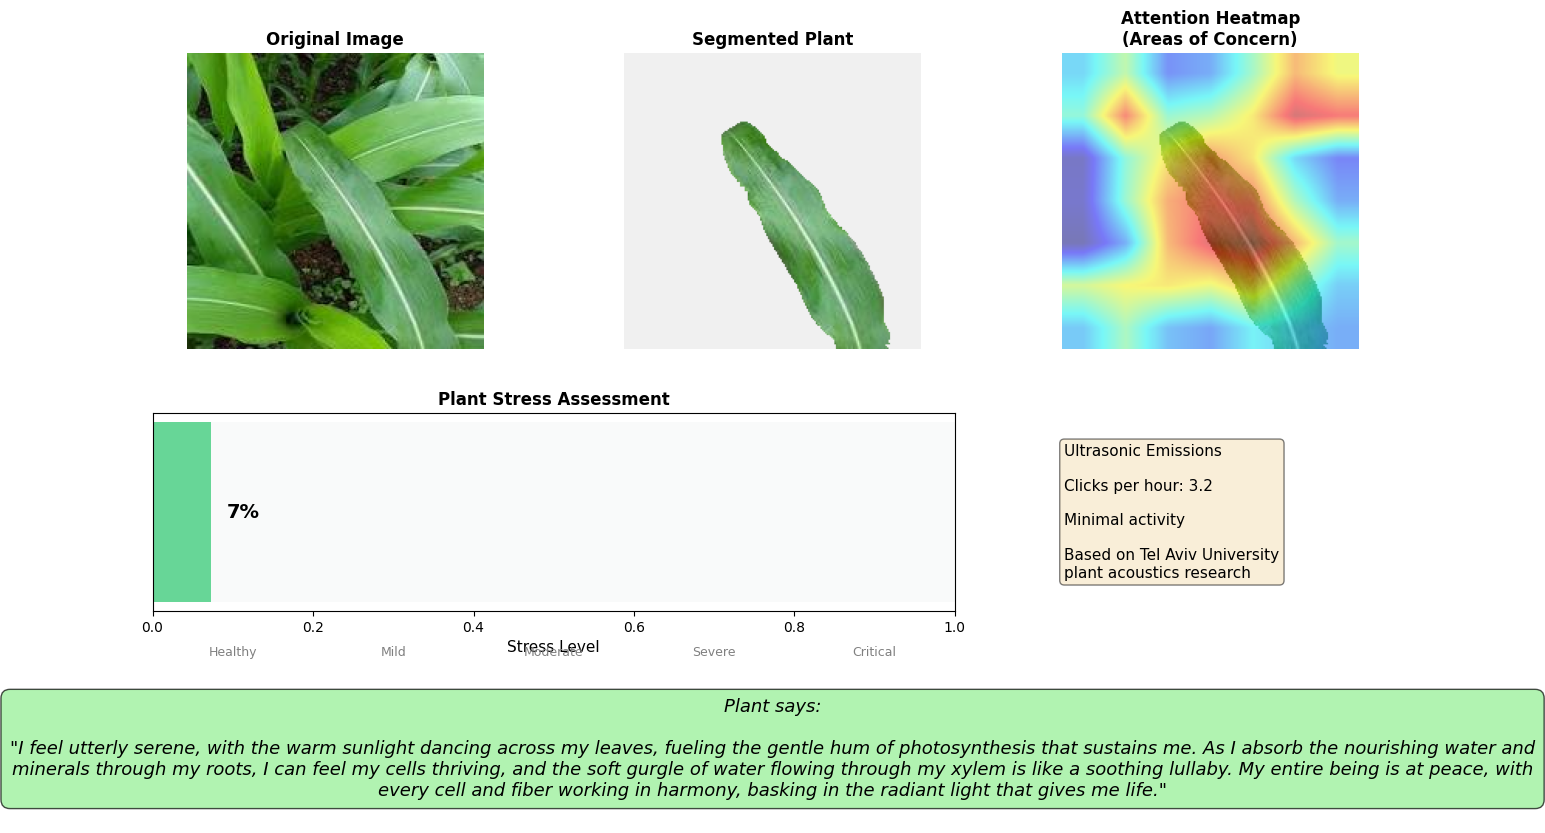


🔊 AUDIO PLAYBACK

🌱 Listen to your plant:



✅ Analysis Complete!


In [17]:
# ============================================
# 12. RUN THE DEMO!
# ============================================

# Option 1: Upload your own image
results = analyze_uploaded_image()

In [19]:
# ============================================
# 14. EXPLORE RESULTS
# ============================================

if results:
    print("\n📊 Analysis Summary")
    print("="*40)
    print(f"Stress Level: {results['stress_level']:.0%}")
    print(f"Healthy: {results['is_healthy']}")
    print(f"Confidence: {results['confidence']:.1%}")
    print(f"Ultrasonic Pops: {results['pops_per_hour']:.1f}/hour")
    print(f"\n🌱 Plant Voice:")
    print(f'"{results["speech_text"]}"')
    print("\n🔊 Audio saved at:", results['audio_path'])


📊 Analysis Summary
Stress Level: 7%
Healthy: True
Confidence: 27.4%
Ultrasonic Pops: 3.2/hour

🌱 Plant Voice:
"I feel utterly serene, with the warm sunlight dancing across my leaves, fueling the gentle hum of photosynthesis that sustains me. As I absorb the nourishing water and minerals through my roots, I can feel my cells thriving, and the soft gurgle of water flowing through my xylem is like a soothing lullaby. My entire being is at peace, with every cell and fiber working in harmony, basking in the radiant light that gives me life."

🔊 Audio saved at: /content/plantwhisper_combined.wav


---

## 🎉 Congratulations!

You've just run **PlantWhisper** - a multimodal AI system that:

1. **Sees** your plant (SAM segmentation + MobileNetV2 classification)
2. **Understands** its stress (Grad-CAM attention + stress estimation)
3. **Recreates** its ultrasonic voice (Tel Aviv research + pitch shifting)
4. **Speaks** its feelings (Groq LLM + Edge-TTS)

### Scientific Foundation
- Based on Khait et al. 2023 (Cell) - plants emit 20-150 kHz ultrasonic clicks when stressed
- Hump-shaped stress curve: healthy plants are quiet, moderate stress = peak emission, severe stress = plant dying = fewer sounds

### Next Steps
- Try with your own plant photos
- Experiment with different voice styles
- Build a mobile app or web interface

---

**Created by Mohith | IIT Bombay | 2026**